In [2]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state =42
)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [4]:
train_input

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ],
       [25. ],
       [40. ],
       [39. ],
       [43. ],
       [22. ],
       [20. ],
       [22. ],
       [24. ],
       [27.5],
       [43. ],
       [40. ],
       [24. ],
       [21. ],
       [27.5],
       [40. ],
       [32.8],
       [26.5],
       [36.5],
       [13.7],
       [22.7],
       [15. ],
       [37. ],
       [35. ],
       [28.7],
       [23.5],
       [39. ],
       [21. ],
       [23. ],
       [22. ],
       [44. ],
       [22.5],
       [19. ],
       [37. ],
       [22. ],
       [25.6],
       [42. ],
       [34.5]])

In [5]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
print(knr.predict([[50]]))

[1033.33333333]


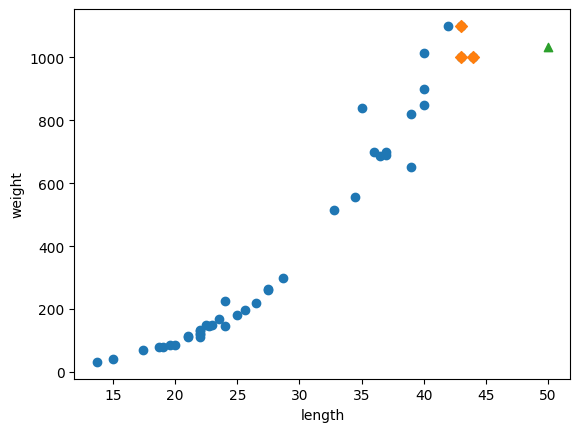

In [7]:
import matplotlib.pyplot as plt

distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)

plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [8]:
print(np.mean(train_target[indexes]))

1033.3333333333333


In [9]:
print(knr.predict([[100]]))

[1033.33333333]


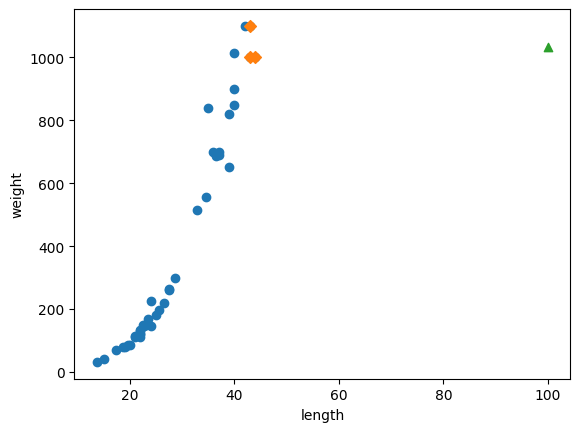

In [10]:
distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)

plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(100, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
# 선형회구
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(train_input, train_target)

print(lr.predict([[50]]))

[1241.83860323]


In [ ]:
# 모델 파라미터
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


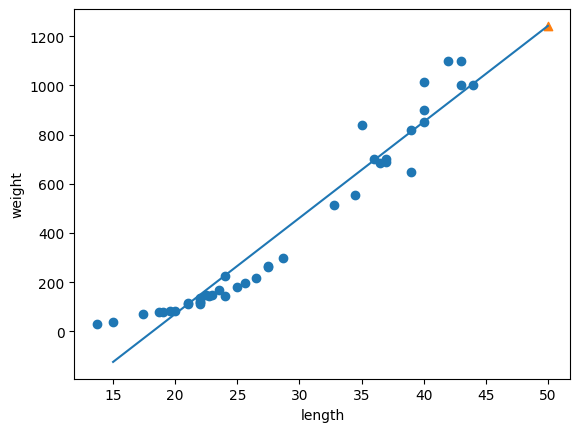

In [ ]:
plt.scatter(train_input, train_target)

plt.plot([15, 50], [15* lr.coef_ + lr.intercept_, 50* lr.coef_ + lr.intercept_])

plt.scatter(50, lr.predict([[50]]), marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [14]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


In [15]:
# 다항회귀
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

print(train_poly.shape, test_poly.shape)


(42, 2) (14, 2)


In [16]:
train_poly

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ],
       [ 625.  ,   25.  ],
       [1600.  ,   40.  ],
       [1521.  ,   39.  ],
       [1849.  ,   43.  ],
       [ 484.  ,   22.  ],
       [ 400.  ,   20.  ],
       [ 484.  ,   22.  ],
       [ 576.  ,   24.  ],
       [ 756.25,   27.5 ],
       [1849.  ,   43.  ],
       [1600.  ,   40.  ],
       [ 576.  ,   24.  ],
       [ 441.  ,   21.  ],
       [ 756.25,   27.5 ],
       [1600.  ,   40.  ],
       [1075.84,   32.8 ],
       [ 702.25,   26.5 ],
       [1332.25,   36.5 ],
       [ 187.69,   13.7 ],
       [ 515.29,   22.7 ],
       [ 225.  ,   15.  ],
       [1369.  ,   37.  ],
       [1225.  ,   35.  ],
       [ 823.69,   28.7 ],
       [ 552.25,   23.5 ],
       [1521.  ,   39.  ],
       [ 441.  ,   21.  ],
       [ 529.  ,   23.  ],
       [ 484.  ,   22.  ],
       [1936.  ,   44.  ],
       [ 506.25,   22.5 ],
       [ 361.  ,   19.  ],
 

In [ ]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

# x제곱 + x + 기울기
print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [19]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827835


In [21]:
lr.coef_[0]

np.float64(1.0143321093767306)

In [22]:
lr.coef_[1]

np.float64(-21.557924978837395)

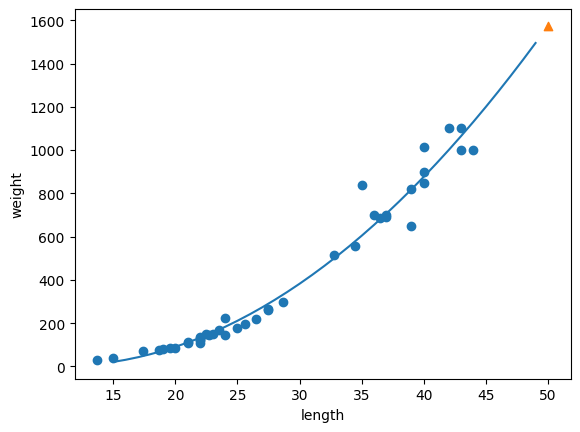

In [23]:
point = np.arange(15, 50)
plt.scatter(train_input, train_target)

plt.plot(point, lr.coef_[0]*point**2 + lr.coef_[1]*point + lr.intercept_)

plt.scatter(50, 1574, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [24]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


### 다중 회귀와 특성 공학과 규제

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [2]:
# target 
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42
)

In [4]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures()
poly.fit(train_input)

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape)
print(poly.get_feature_names_out())

(42, 10)
['1' 'length' ' height' ' width' 'length^2' 'length  height'
 'length  width' ' height^2' ' height  width' ' width^2']


In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9999999999999999
-144.40489342874613


In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=5)
poly.fit(train_input)

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9999999999999999
-144.40489342874613


### 규제 : 과대적합 줄이기

In [6]:
# L2 규제 (릿지 회귀)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

ridge = Ridge(alpha=1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896101671037343
0.9790693977615387


In [21]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570365
0.9827976465386797


In [7]:
ridge = Ridge(alpha=0.044)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9907827381773738
0.983277348660457


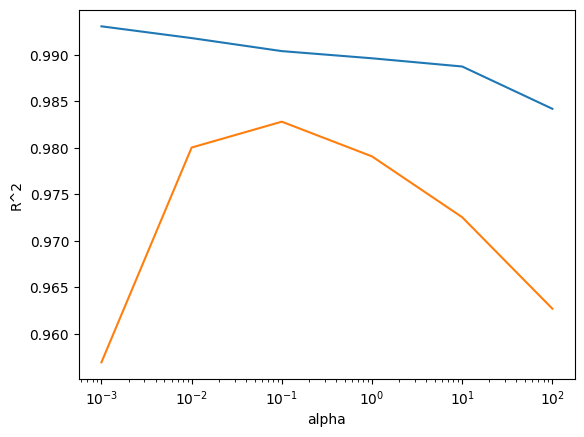

In [23]:
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

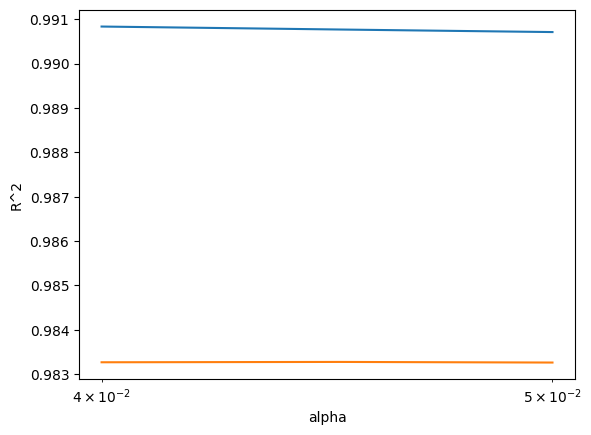

In [36]:
train_score = []
test_score = []

alpha_list = [0.040, 0.045, 0.050]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [46]:
# L1 규제 (라쏘 회귀)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.989789897208096
0.9800593698421884


/home/user/source/python310/.venv_python310/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/home/user/source/python310/.venv_python310/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


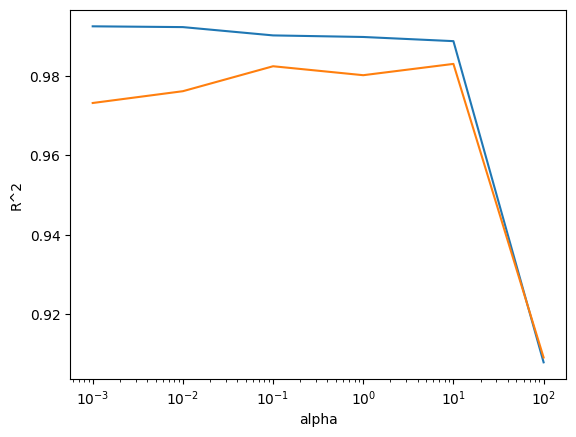

In [48]:
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [8]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9888067471131867
0.9824470598706695


In [53]:
# 전체 특성의 개수
print(len(lasso.coef_))

# 라쏘 모델이 사용하지 않은 특성의 개수
print(np.sum(lasso.coef_ == 0))

56
41


### XGBoost 회귀

In [10]:
# XGBoost 회귀 모델
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(train_scaled, train_target)

print(f"Train Score: {xgb.score(train_scaled, train_target):.4f}")
print(f"Test Score: {xgb.score(test_scaled, test_target):.4f}")

Train Score: 1.0000
Test Score: 0.9615


In [11]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

# XGBoost 주요 하이퍼파라미터
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42), param_grid, 
                        cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(train_scaled, train_target)

print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Best CV Score: {xgb_grid.best_score_:.4f}")
print(f"Train Score: {xgb_grid.score(train_scaled, train_target):.4f}")
print(f"Test Score: {xgb_grid.score(test_scaled, test_target):.4f}")

Best Parameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best CV Score: 0.9400
Train Score: 1.0000
Test Score: 0.9609


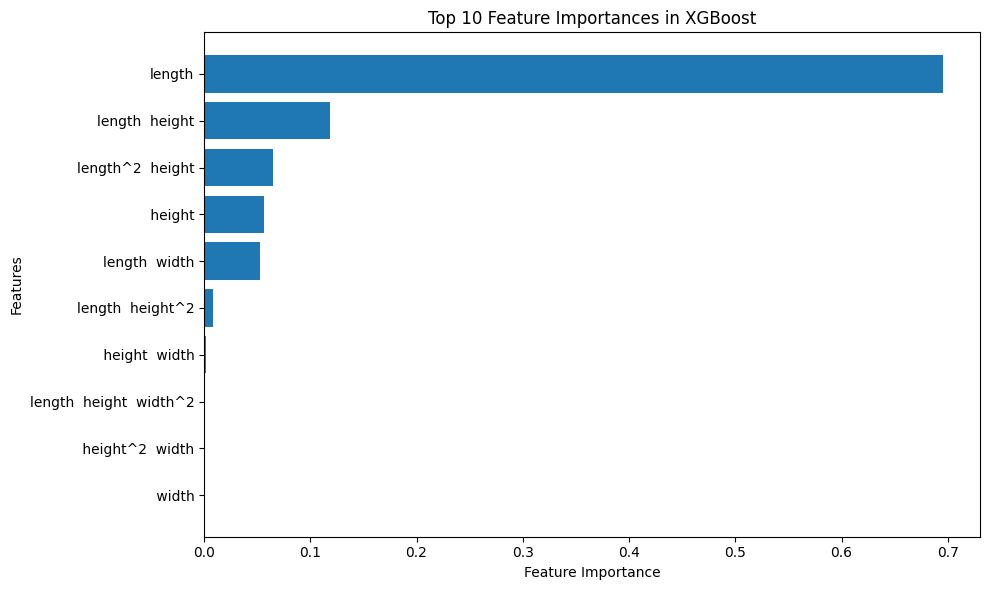

In [12]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt

best_xgb = xgb_grid.best_estimator_
feature_importance = best_xgb.feature_importances_

# 특성 이름 가져오기
feature_names = poly.get_feature_names_out()

# 중요도가 높은 상위 10개 특성만 표시
indices = np.argsort(feature_importance)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances in XGBoost')
plt.tight_layout()
plt.show()

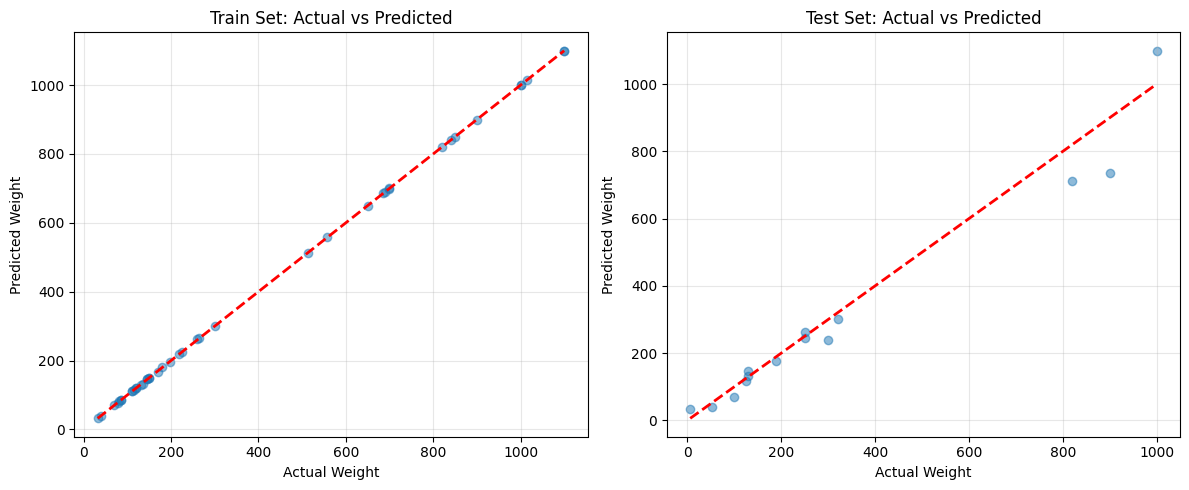

In [13]:
# 예측값 vs 실제값 비교
y_pred_train = best_xgb.predict(train_scaled)
y_pred_test = best_xgb.predict(test_scaled)

plt.figure(figsize=(12, 5))

# Train set
plt.subplot(1, 2, 1)
plt.scatter(train_target, y_pred_train, alpha=0.5)
plt.plot([train_target.min(), train_target.max()], 
         [train_target.min(), train_target.max()], 'r--', lw=2)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('Train Set: Actual vs Predicted')
plt.grid(True, alpha=0.3)

# Test set
plt.subplot(1, 2, 2)
plt.scatter(test_target, y_pred_test, alpha=0.5)
plt.plot([test_target.min(), test_target.max()], 
         [test_target.min(), test_target.max()], 'r--', lw=2)
plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title('Test Set: Actual vs Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 교차 검증을 통한 모델 평가
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_xgb, train_scaled, train_target, 
                             cv=5, scoring='r2')

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation Scores: [0.97211489 0.98495565 0.92513371 0.83523252 0.98239067]
Mean CV Score: 0.9400 (+/- 0.1133)


In [15]:
# 평가 지표 비교 (MAE, MSE, RMSE, R²)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train = best_xgb.predict(train_scaled)
y_pred_test = best_xgb.predict(test_scaled)

print("=" * 50)
print("Train Set Metrics:")
print("=" * 50)
print(f"MAE:  {mean_absolute_error(train_target, y_pred_train):.4f}")
print(f"MSE:  {mean_squared_error(train_target, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(train_target, y_pred_train)):.4f}")
print(f"R²:   {r2_score(train_target, y_pred_train):.4f}")

print("\n" + "=" * 50)
print("Test Set Metrics:")
print("=" * 50)
print(f"MAE:  {mean_absolute_error(test_target, y_pred_test):.4f}")
print(f"MSE:  {mean_squared_error(test_target, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_target, y_pred_test)):.4f}")
print(f"R²:   {r2_score(test_target, y_pred_test):.4f}")

Train Set Metrics:
MAE:  0.7710
MSE:  1.2056
RMSE: 1.0980
R²:   1.0000

Test Set Metrics:
MAE:  41.3908
MSE:  3925.0474
RMSE: 62.6502
R²:   0.9609


Model Performance Comparison
Model                         Train R²      Test R² Difference
------------------------------------------------------------
Linear Regression               1.0000    -144.4049   145.4049
Ridge (alpha=0.044)             0.9908       0.9833     0.0075
Lasso (alpha=10)                0.9888       0.9824     0.0064
XGBoost                         1.0000       0.9609     0.0391


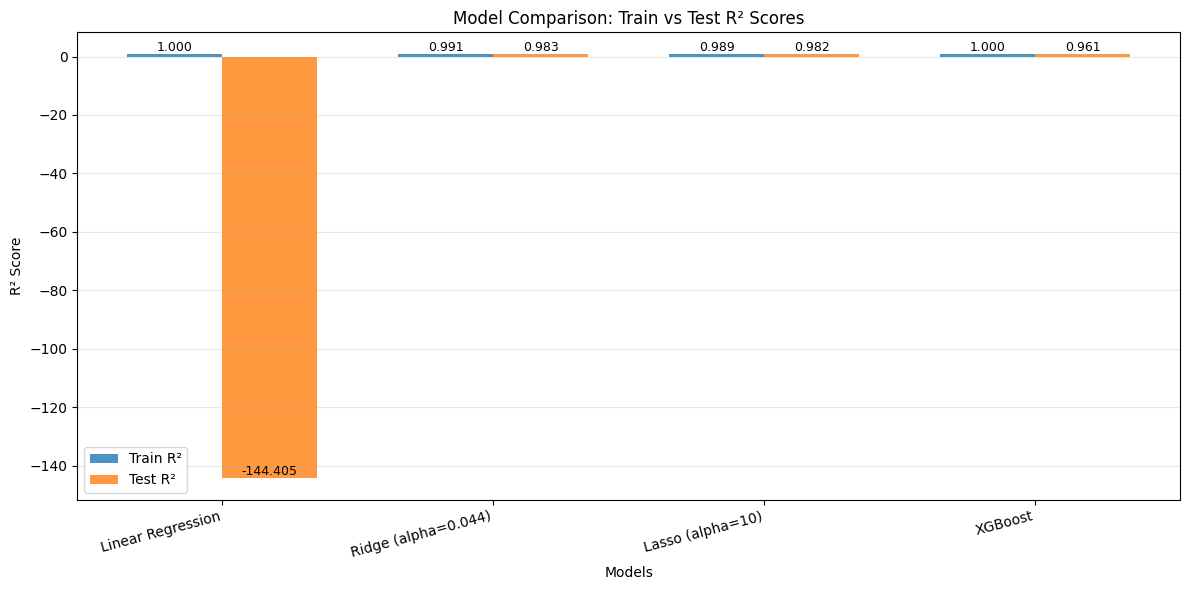

In [16]:
# 모델 비교: 선형회귀 vs Ridge vs Lasso vs XGBoost
models_comparison = {
    'Linear Regression': (lr.score(train_poly, train_target), lr.score(test_poly, test_target)),
    'Ridge (alpha=0.044)': (ridge.score(train_scaled, train_target), ridge.score(test_scaled, test_target)),
    'Lasso (alpha=10)': (lasso.score(train_scaled, train_target), lasso.score(test_scaled, test_target)),
    'XGBoost': (best_xgb.score(train_scaled, train_target), best_xgb.score(test_scaled, test_target))
}

print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)
print(f"{'Model':<25} {'Train R²':>12} {'Test R²':>12} {'Difference':>10}")
print("-" * 60)

for model_name, (train_score, test_score) in models_comparison.items():
    diff = train_score - test_score
    print(f"{model_name:<25} {train_score:>12.4f} {test_score:>12.4f} {diff:>10.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
models = list(models_comparison.keys())
train_scores = [score[0] for score in models_comparison.values()]
test_scores = [score[1] for score in models_comparison.values()]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Train R²', alpha=0.8)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test R²', alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: Train vs Test R² Scores')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()